In [2]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

Cloning into 'k_shortest_path_with_diversity'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (280/280), done.
remote: Compressing objects: 100% (240/240), done.
remote: Total 444 (delta 180), reused 61 (delta 40), pack-reused 164 (from 1)
Receiving objects: 100% (444/444), 404.04 KiB | 3.88 MiB/s, done.
Resolving deltas: 100% (279/279), done.


In [9]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [10]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_bar_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Yen, FindKSPD_Minus

In [11]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)


    return times, num_paths

In [23]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [13]:
download_and_prepare_graphs()

k_to_find = 10
diversity_threshold = 0.6

Already exists, skipping: /content/graph-data/web-Google.txt
Already exists, skipping: /content/graph-data/wiki-Talk.txt
Already exists, skipping: /content/graph-data/USA-road-d.FLA.gr
Already exists, skipping: /content/graph-data/USA-road-d.COL.gr


In [49]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 10
G, node_pairs = upload_graph(web_google_path, num_pairs)

In [25]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

working with KSPD

Comparing algorithms for SRC: 90561, DEST: 361096

Comparing algorithms for SRC: 254499, DEST: 291975

Comparing algorithms for SRC: 904392, DEST: 328793

Comparing algorithms for SRC: 703848, DEST: 217437

Comparing algorithms for SRC: 89689, DEST: 614411

Comparing algorithms for SRC: 45099, DEST: 287354

Comparing algorithms for SRC: 234001, DEST: 244920

Comparing algorithms for SRC: 41128, DEST: 99746

Comparing algorithms for SRC: 88498, DEST: 833008

Comparing algorithms for SRC: 258658, DEST: 884488


In [30]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

working with KSPD_Minus

Comparing algorithms for SRC: 90561, DEST: 361096

Comparing algorithms for SRC: 254499, DEST: 291975

Comparing algorithms for SRC: 904392, DEST: 328793

Comparing algorithms for SRC: 703848, DEST: 217437

Comparing algorithms for SRC: 89689, DEST: 614411

Comparing algorithms for SRC: 45099, DEST: 287354

Comparing algorithms for SRC: 234001, DEST: 244920

Comparing algorithms for SRC: 41128, DEST: 99746

Comparing algorithms for SRC: 88498, DEST: 833008

Comparing algorithms for SRC: 258658, DEST: 884488


In [53]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6


In [54]:
web_google_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

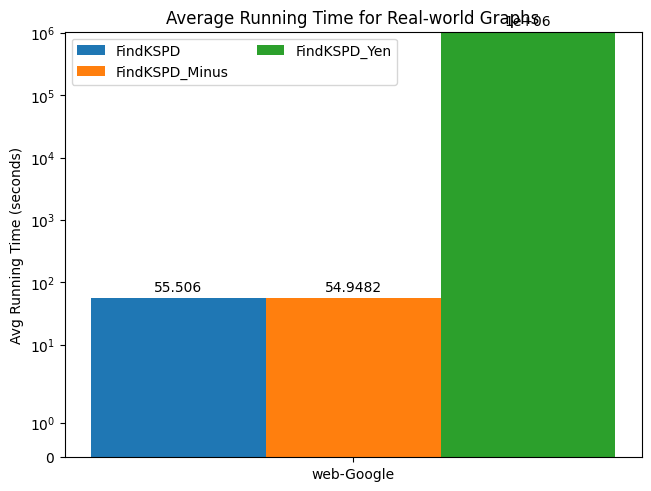

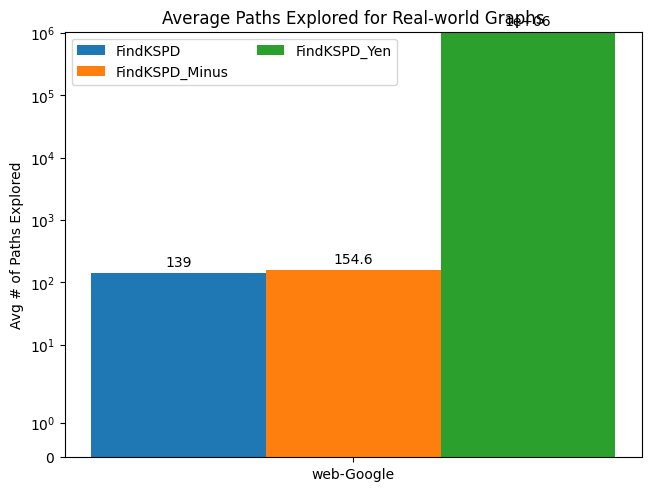

In [55]:
graph_types = ("web-Google",)

algorithms_time = {
    'FindKSPD':       [web_google_result[0][0]],  # index 0 = avg_time
    'FindKSPD_Minus': [web_google_result[1][0]],
    'FindKSPD_Yen':   [web_google_result[2][0]],
}

algorithms_paths = {
    'FindKSPD':       [web_google_result[0][1]],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [web_google_result[1][1]],
    'FindKSPD_Yen':   [web_google_result[2][1]],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [56]:
del G
gc.collect()

10922

In [57]:
wiki_talk_path  = "/content/graph-data/wiki-Talk.txt"
num_pairs = 10
G, node_pairs = upload_graph(wiki_talk_path, num_pairs)

In [58]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

working with KSPD

Comparing algorithms for SRC: 1184188, DEST: 2263398

Comparing algorithms for SRC: 1333144, DEST: 1333145

Comparing algorithms for SRC: 277152, DEST: 341741

Comparing algorithms for SRC: 306213, DEST: 1211223

Comparing algorithms for SRC: 30617, DEST: 1449918

Comparing algorithms for SRC: 432264, DEST: 2269284

Comparing algorithms for SRC: 1969700, DEST: 1969701

Comparing algorithms for SRC: 1679847, DEST: 1680248

Comparing algorithms for SRC: 1765911, DEST: 753683

Comparing algorithms for SRC: 123426, DEST: 2064075


In [59]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

working with KSPD_Minus

Comparing algorithms for SRC: 1184188, DEST: 2263398

Comparing algorithms for SRC: 1333144, DEST: 1333145

Comparing algorithms for SRC: 277152, DEST: 341741

Comparing algorithms for SRC: 306213, DEST: 1211223

Comparing algorithms for SRC: 30617, DEST: 1449918

Comparing algorithms for SRC: 432264, DEST: 2269284

Comparing algorithms for SRC: 1969700, DEST: 1969701

Comparing algorithms for SRC: 1679847, DEST: 1680248

Comparing algorithms for SRC: 1765911, DEST: 753683

Comparing algorithms for SRC: 123426, DEST: 2064075


In [60]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [61]:
wiki_talk_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

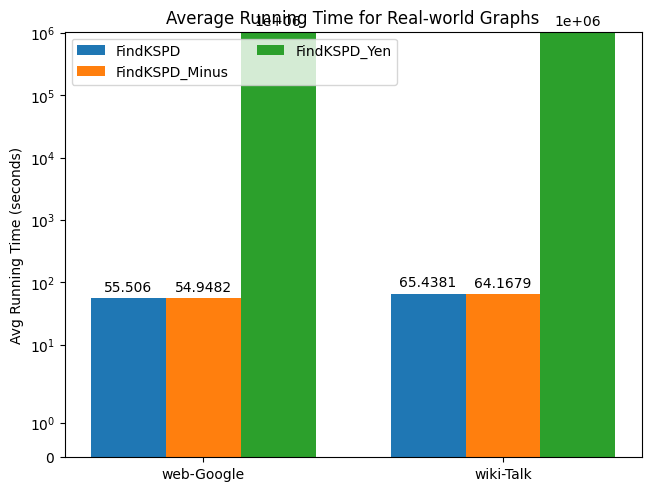

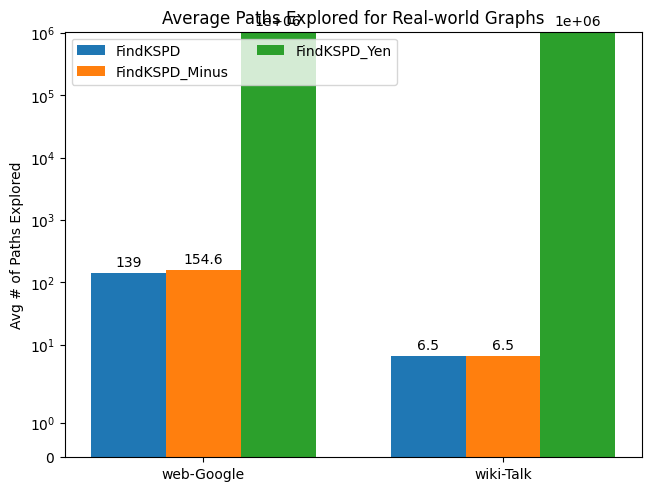

In [62]:
all_results = [web_google_result, wiki_talk_result]

graph_types = ("web-Google", "wiki-Talk")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [63]:
del G
gc.collect()

2525169

In [64]:
roadFLA_path    = "/content/graph-data/USA-road-d.FLA.gr"
num_pairs = 10
G, node_pairs = upload_graph(roadFLA_path, num_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

working with KSPD

Comparing algorithms for SRC: 679986, DEST: 725236


In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

working with KSPD_Minus

Comparing algorithms for SRC: 1184188, DEST: 2263398

Comparing algorithms for SRC: 1333144, DEST: 1333145

Comparing algorithms for SRC: 277152, DEST: 341741

Comparing algorithms for SRC: 306213, DEST: 1211223

Comparing algorithms for SRC: 30617, DEST: 1449918

Comparing algorithms for SRC: 432264, DEST: 2269284

Comparing algorithms for SRC: 1969700, DEST: 1969701

Comparing algorithms for SRC: 1679847, DEST: 1680248

Comparing algorithms for SRC: 1765911, DEST: 753683

Comparing algorithms for SRC: 123426, DEST: 2064075


In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadFLA_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

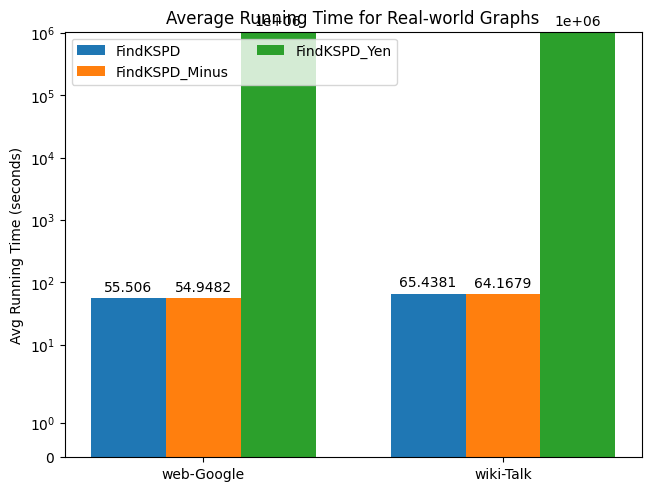

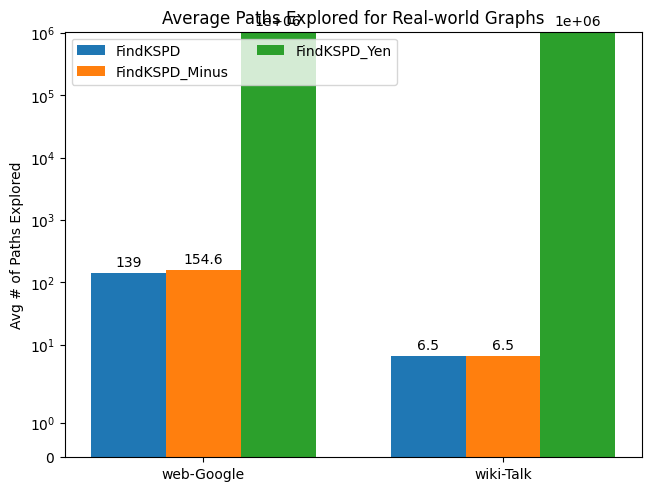

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadFLA_result]

graph_types = ("web-Google", "wiki-Talk", "RoadFLA")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
roadCOL_path    = "/content/graph-data/USA-road-d.COL.gr"


print("working on wiki-talk graph")
wiki_talk_result  = find_results_based_on_graph(wiki_talk_path,  k_to_find, diversity_threshold)
print("working on roadFLA graph")
roadFLA_result    = find_results_based_on_graph(roadFLA_path,    k_to_find, diversity_threshold)
print("working on roadCOL graph")
roadCOL_result    = find_results_based_on_graph(roadCOL_path,    k_to_find, diversity_threshold)

# Each result tuple: (kspd_result, kspd_minus_result, kspd_yen_result)
# Each algorithm result: (avg_time, avg_num_paths, all_times_list, all_num_paths_list)
all_results = [web_google_result, wiki_talk_result, roadCOL_result, roadFLA_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL", "RoadFLA")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

all_kspd_times = []
all_kspd_minus_times = []
all_kspd_yen_times = []

all_kspd_num_paths = []
all_kspd_minus_num_paths = []
all_kspd_yen_num_paths = []

for graph_result in all_results:
    all_kspd_times.extend(graph_result[0][2])
    all_kspd_num_paths.extend(graph_result[0][3])

    all_kspd_minus_times.extend(graph_result[1][2])
    all_kspd_minus_num_paths.extend(graph_result[1][3])

    all_kspd_yen_times.extend(graph_result[2][2])
    all_kspd_yen_num_paths.extend(graph_result[2][3])

# Plotting distributions for times
plot_configs_time = [
    ('FindKSPD Execution Times', all_kspd_times, 'skyblue'),
    ('FindKSPD_Minus Execution Times', all_kspd_minus_times, 'lightcoral'),
    ('FindKSPD_Yen Execution Times', all_kspd_yen_times, 'lightgreen'),
]
draw_time_distribution(plot_configs_time)

# Plotting distributions for number of paths
plot_configs_num_paths = [
    ('FindKSPD Number of Paths Explored', all_kspd_num_paths, 'skyblue'),
    ('FindKSPD_Minus Number of Paths Explored', all_kspd_minus_num_paths, 'lightcoral'),
    ('FindKSPD_Yen Number of Paths Explored', all_kspd_yen_num_paths, 'lightgreen'),
]
draw_num_of_path_distribution(plot_configs_num_paths)